<a href="https://colab.research.google.com/github/kat-miao/CUNY-Data-Analytics/blob/main/Capstone_Project_QPL_Energy_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is a database from DCAS: energy usage and cost across the Queens Public Library building portfolio. I received permission to use the database for my project as long as sensitive information is removed, which I did.



My goal was to convert the Excel spreadsheet to use in Python/Google CoLabs because the spreadsheet was slowing down in Excel when I was conducting calculations. I hope I can learn to append the code with additional csv files as I update the data, but that is for another time.

While I've conducted the same calculations before in Excel and Microsoft PowerBI, it was helpful using Python through this process while using my experience from prior projects.

For this project's purpose, I plan to answer the question, "How does Central Library's energy usage (mmBTUs) change over time?"

In [1]:
# importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
%matplotlib inline

In [2]:
# read in database by uploading to Google Drive and replacing the tail end of the unique URL link with "/gviz/tq?tqx=out:csv"
df = pd.read_csv('https://docs.google.com/spreadsheets/d/1luTmMvpMpKnacbh915SQSxz14nXyiTgG-rtndDoFRzA/gviz/tq?tqx=out:csv')

Exploring and cleaning data

In [3]:
# original size of data
df.shape
#(103096, 16)

(103096, 15)

In [4]:
# dropping columns with sensitive information - if you can see it, let me know and I will remove it on the backend before reading in the database
df = df.drop(columns = ["OECID"])

In [5]:
# see general data
df.head()

,Agency,Facility Name,Facility Address,Parameter,Borough,Block,LotNumber,OrderNumber,Date,Fiscal Year,Quantity,mmBTUs,kBtu,MTCO2e
0,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Gas (Therms),4,173,16,7.0,7/1/2009,#ERROR!,5,#ERROR!,#ERROR!,#ERROR!
1,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Gas Cost ($),4,173,16,9.0,7/1/2009,#ERROR!,28,#ERROR!,#ERROR!,#ERROR!
2,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Electricity Usage (KWH),4,173,16,1.0,7/1/2009,#ERROR!,"11,200",#ERROR!,#ERROR!,#ERROR!
3,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Electricity Demand (KW),4,173,16,3.0,7/1/2009,#ERROR!,46,#ERROR!,#ERROR!,#ERROR!
4,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Electricity Cost ($),4,173,16,5.0,7/1/2009,#ERROR!,"2,132",#ERROR!,#ERROR!,#ERROR!


In [6]:
# data cleaning because these columns were tied to formulas in ExCEL. I hope to re-add these calculated columns when I have the time.
clean_columns = ["Fiscal Year", "mmBTUs", "kBtu", "MTCO2e"]
df[clean_columns] = df[clean_columns].replace("#ERROR!", np.nan)

/tmp/ipykernel_3254/583117004.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[clean_columns] = df[clean_columns].replace("#ERROR!", np.nan)


In [7]:
# dropping additional columns
df = df.drop(columns = ["Fiscal Year", "mmBTUs", "kBtu", "MTCO2e"])

In [8]:
# checking to see data preview again to see if changes were successfully made
df.head()

,Agency,Facility Name,Facility Address,Parameter,Borough,Block,LotNumber,OrderNumber,Date,Quantity
0,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Gas (Therms),4,173,16,7.0,7/1/2009,5
1,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Gas Cost ($),4,173,16,9.0,7/1/2009,28
2,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Electricity Usage (KWH),4,173,16,1.0,7/1/2009,"11,200"
3,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Electricity Demand (KW),4,173,16,3.0,7/1/2009,46
4,Queens Library,Sunnyside Library,43-06 Greenpoint Ave,Electricity Cost ($),4,173,16,5.0,7/1/2009,"2,132"


In [9]:
# see data type of the columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103096 entries, 0 to 103095
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Agency            95142 non-null   object 
 1   Facility Name     103096 non-null  object 
 2   Facility Address  103096 non-null  object 
 3   Parameter         103096 non-null  object 
 4   Borough           103096 non-null  int64  
 5   Block             103096 non-null  int64  
 6   LotNumber         103096 non-null  int64  
 7   OrderNumber       102495 non-null  float64
 8   Date              103096 non-null  object 
 9   Quantity          89933 non-null   object 
dtypes: float64(1), int64(3), object(6)
memory usage: 7.9+ MB


In [10]:
# change "Date" column to a date data type
df["Date"] = pd.to_datetime(df["Date"])

In [11]:
# checking to see if the conversion worked
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103096 entries, 0 to 103095
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   Agency            95142 non-null   object        
 1   Facility Name     103096 non-null  object        
 2   Facility Address  103096 non-null  object        
 3   Parameter         103096 non-null  object        
 4   Borough           103096 non-null  int64         
 5   Block             103096 non-null  int64         
 6   LotNumber         103096 non-null  int64         
 7   OrderNumber       102495 non-null  float64       
 8   Date              103096 non-null  datetime64[ns]
 9   Quantity          89933 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(3), object(5)
memory usage: 7.9+ MB


In [12]:
#seeing the oldest and most recent date
print(df["Date"].min())
print(df["Date"].max())

2007-10-01 00:00:00
2026-01-01 00:00:00


In [13]:
#seeing the names in "Facility Name" column
df["Facility Name"].unique()

array(['Sunnyside Library', 'Elmhurst Library', 'Poppenhusen Library',
       'Woodhaven Library', 'Woodside Library', 'East Elmhurst Library',
       'Steinway Library', 'Glendale Library', 'Ridgewood Library',
       'Richmond Hill Library', 'Hollis Library',
       'Queens Village Library', 'South Hollis Library',
       'Jackson Heights Library', 'Laurelton Library',
       'Windsor Park Library', 'Glen Oaks Library', 'Flushing Library',
       'Broadway Library', 'Forest Hills Library',
       'Fresh Meadows Library', 'Douglaston-Little Neck Library',
       'Mitchell-Linden Library', 'Rosedale Library',
       'Howard Beach Library', 'Bayside Library', 'Central Library (QPL)',
       'Kew Gardens Hills Library', 'Lefrak City Library (Former)',
       'East Flushing Library', 'Astoria Library', 'Corona Library',
       'St. Albans Library', 'Rochdale Village Library',
       'Auburndale Library', 'Briarwood Library', 'Whitestone Library',
       'Baisley Park Library', 'South Ozon

In [14]:
# number of unique names in "Facility Name"
df["Facility Name"].unique().size

73

In [15]:
# seeing unique Parameter names
df["Parameter"].unique()

array(['Gas (Therms)', 'Gas Cost ($)', 'Electricity Usage (KWH)',
       'Electricity Demand (KW)', 'Electricity Cost ($)',
       'Total Usage (mmBTUs)', 'Total Cost ($)',
       'Electricity Usage (kWh)', 'Electricity Demand (kW)'], dtype=object)

In [16]:
# number of unique "Parameter" names
df["Parameter"].unique().size

9

Selecting data for analysis

In [17]:
#narrowing down columns to subset data then seeing the preview of data

df_subset = df[["Facility Name", "Parameter", "Date", "Quantity"]]
df_subset.head()

,Facility Name,Parameter,Date,Quantity
0,Sunnyside Library,Gas (Therms),2009-07-01,5
1,Sunnyside Library,Gas Cost ($),2009-07-01,28
2,Sunnyside Library,Electricity Usage (KWH),2009-07-01,"11,200"
3,Sunnyside Library,Electricity Demand (KW),2009-07-01,46
4,Sunnyside Library,Electricity Cost ($),2009-07-01,"2,132"


In [18]:
# describe to see some stats didn't show me anything.
df_subset.describe()

,Date
count,103096
mean,2017-09-30 07:44:19.424226048
min,2007-10-01 00:00:00
25%,2013-08-01 00:00:00
50%,2017-10-01 00:00:00
75%,2021-12-01 00:00:00
max,2026-01-01 00:00:00


In [19]:
# using groupby to group data together in buckets of facility name then parameters then dates and summing the quantities.
df_subset.groupby(["Facility Name", "Parameter", "Date"])["Quantity"].sum()

Facility Name     Parameter             Date      
Arverne Library   Electricity Cost ($)  2009-07-01    2,007
                                        2009-08-01    1,937
                                        2009-09-01    2,093
                                        2009-10-01    1,321
                                        2009-11-01    1,134
                                                      ...  
Woodside Library  Total Usage (mmBTUs)  2025-09-01       30
                                        2025-10-01       23
                                        2025-11-01       74
                                        2025-12-01      194
                                        2026-01-01      213
Name: Quantity, Length: 97413, dtype: object

In [20]:
# groupby was a lot to work with, so I picked a single facility name and parameter to work with
# selected Central Library for Facility Name and Total Usage (mmbtus) for Parameter then saw a preview of the data

central_usage = df_subset[(df_subset["Facility Name"] == "Central Library (QPL)") & (df_subset["Parameter"] == "Total Usage (mmBTUs)")]
central_usage.head(20)

,Facility Name,Parameter,Date,Quantity
205,Central Library (QPL),Total Usage (mmBTUs),2009-07-01,"3,291"
722,Central Library (QPL),Total Usage (mmBTUs),2009-08-01,"3,314"
1239,Central Library (QPL),Total Usage (mmBTUs),2009-09-01,"2,977"
1756,Central Library (QPL),Total Usage (mmBTUs),2009-10-01,"1,735"
2273,Central Library (QPL),Total Usage (mmBTUs),2009-11-01,"1,203"
2790,Central Library (QPL),Total Usage (mmBTUs),2009-12-01,"1,736"
3307,Central Library (QPL),Total Usage (mmBTUs),2010-01-01,"1,485"
3824,Central Library (QPL),Total Usage (mmBTUs),2010-02-01,"1,640"
4341,Central Library (QPL),Total Usage (mmBTUs),2010-03-01,"1,259"
4858,Central Library (QPL),Total Usage (mmBTUs),2010-04-01,"1,206"


In [21]:
# it's easier to use the groupby function now

central_usage.groupby(["Facility Name", "Parameter", "Date"])["Quantity"].sum()

Facility Name          Parameter             Date      
Central Library (QPL)  Total Usage (mmBTUs)  2009-07-01    3,291
                                             2009-08-01    3,314
                                             2009-09-01    2,977
                                             2009-10-01    1,735
                                             2009-11-01    1,203
                                                           ...  
                                             2025-09-01    1,633
                                             2025-10-01    1,763
                                             2025-11-01    1,636
                                             2025-12-01    1,586
                                             2026-01-01    2,229
Name: Quantity, Length: 199, dtype: object

Data Visualization

In [22]:
# Converting "Date" column is in datetime format
# using .loc[:,] because Colab recommended. It's used for subsetted data
central_usage.loc[:,'Date'] = pd.to_datetime(central_usage['Date'])

In [23]:
# Convert 'Quantity' to numeric, handling commas and errors
# .astype(str).str.replace(",", "", regex=False) is used to convert all the values to strings and to remove the commas so they can be intrepetted as numbers.
# pd.to_numeric is used to convert the values to numbers.
# errors="coerce" is for replacing any values that can't be converted to numbers with NaN.

central_usage["Quantity"] = central_usage["Quantity"].astype(str).str.replace(",", "", regex=False)
central_usage["Quantity"] = pd.to_numeric(central_usage["Quantity"], errors="coerce")

/tmp/ipykernel_3254/1932113701.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_usage["Quantity"] = central_usage["Quantity"].astype(str).str.replace(",", "", regex=False)
/tmp/ipykernel_3254/1932113701.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  central_usage["Quantity"] = pd.to_numeric(central_usage["Quantity"], errors="coerce")


<Axes: title={'center': "Central Library's Energy Usage Over Time"}, xlabel='Year', ylabel='Total Usage (mmBTUs)'>

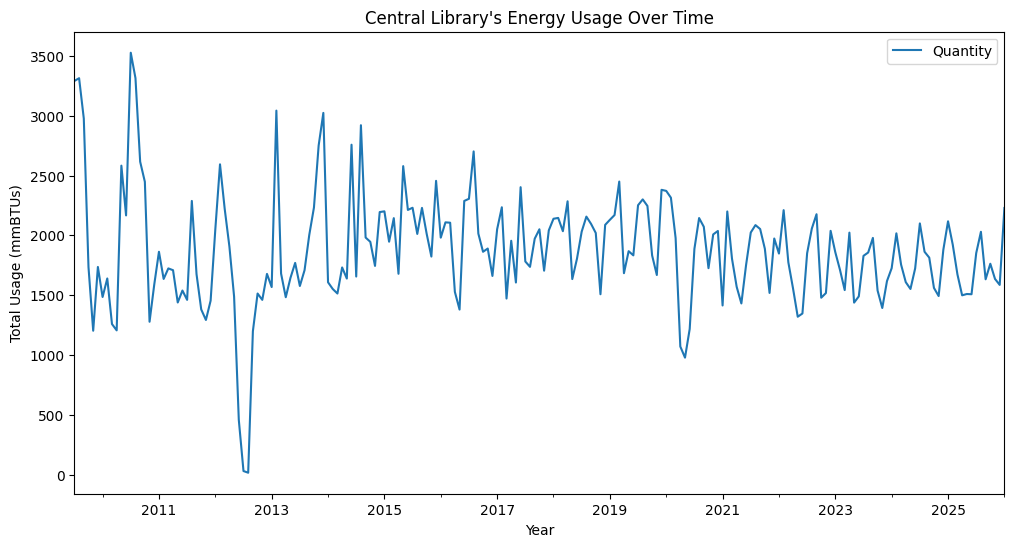

In [24]:
central_usage.plot(
    x="Date",
    y="Quantity",
    kind="line",
    xlabel="Year",
    ylabel="Total Usage (mmBTUs)",
    title="Central Library's Energy Usage Over Time",
    figsize=(12, 6)
)

Conclusion: Central Library's total energy usage in mmBTUs has fluctuated a lot more before 2015. There is missing data for when it dropped to zero in the summer of 2012. I'm unsure what caused the huge peak in 2010, so I would have to ask around and see what happened. We can also see the pandemic drop in energy usage in 2020. Energy usage on an annual basis has a similar season pattern after 2021, hovering around 1800 mmbtus a year.